In [1]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
from functions_fcsuml import *
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load data
df = pd.read_parquet('Optimal_clustering_260304.parquet')
df.head()


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,1.0,0.493412,0.867952,0.107071,0.121795,0.005310,0.446429,0.0,0.000000,0.0,...,0.0,0.0,0.616053,0.417631,0.473857,0.570476,0.346713,0.839638,0.380631,0.924178
1,1.0,0.600605,0.874881,0.106061,0.144231,0.020370,0.464286,0.0,0.000000,0.0,...,0.0,0.0,0.545813,0.453476,0.473857,0.570476,0.350574,0.000000,0.226061,0.000000
2,1.0,0.552911,0.848032,0.047475,0.072115,0.008419,0.714286,0.0,0.000000,0.0,...,0.0,0.0,0.582387,0.483412,0.473857,0.570476,0.344630,0.862664,0.380631,0.934938
3,1.0,0.592690,0.913734,0.109091,0.384615,0.003681,0.410714,0.0,0.000000,0.0,...,0.0,0.0,0.582387,0.483412,0.473857,0.570476,0.344630,0.862664,0.380631,0.934938
4,1.0,0.537834,0.833929,0.059596,0.214744,0.002406,0.482143,0.0,0.098361,0.0,...,0.0,0.0,0.545813,0.453476,0.473857,0.570476,0.350574,0.000000,0.226061,0.000000


In [2]:
name_list = ['norm_data_260303.parquet', 'norm_targets_260303.parquet', 'norm_testing_targets_260303.parquet', 'norm_validation_targets_260303.parquet',
             'norm_validation_data_260303.parquet', 'norm_testing_data_260303.parquet']
data_list = []

for i in range(len(name_list)):
    temp = pd.read_parquet(name_list[i])
    data_list.append((temp.to_numpy()))

norm_data, norm_targets, norm_testing_targets, norm_validation_targets, norm_validation_data, norm_testing_data = data_list

[    0.  9025. 10601. 15195. 21047. 24458. 28439. 34769. 45497. 52104.
 54757. 63679. 65231. 71814. 73304.]
avg sil: -0.021486159044237882 
 cluster silhouettes: 
 [[ 1.00000000e+00  2.28574958e-01]
 [ 2.00000000e+00 -4.21952760e-02]
 [ 3.00000000e+00  1.02827574e-01]
 [ 4.00000000e+00  6.03137002e-02]
 [ 5.00000000e+00 -3.45975784e-02]
 [ 6.00000000e+00 -8.92180308e-02]
 [ 7.00000000e+00 -1.53167586e-01]
 [ 8.00000000e+00 -2.59679953e-04]
 [ 9.00000000e+00  1.35450667e-01]
 [ 1.00000000e+01 -5.42525693e-02]
 [ 1.10000000e+01  1.82342211e-01]
 [ 1.20000000e+01  1.08353301e-01]
 [ 1.30000000e+01  8.80817946e-02]] 
 argmax 0


c:\Users\Projektlotsarna\Code\Exjobb\Finding-comparable-sales-using-macine-learning\functions_fcsuml.py:95: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


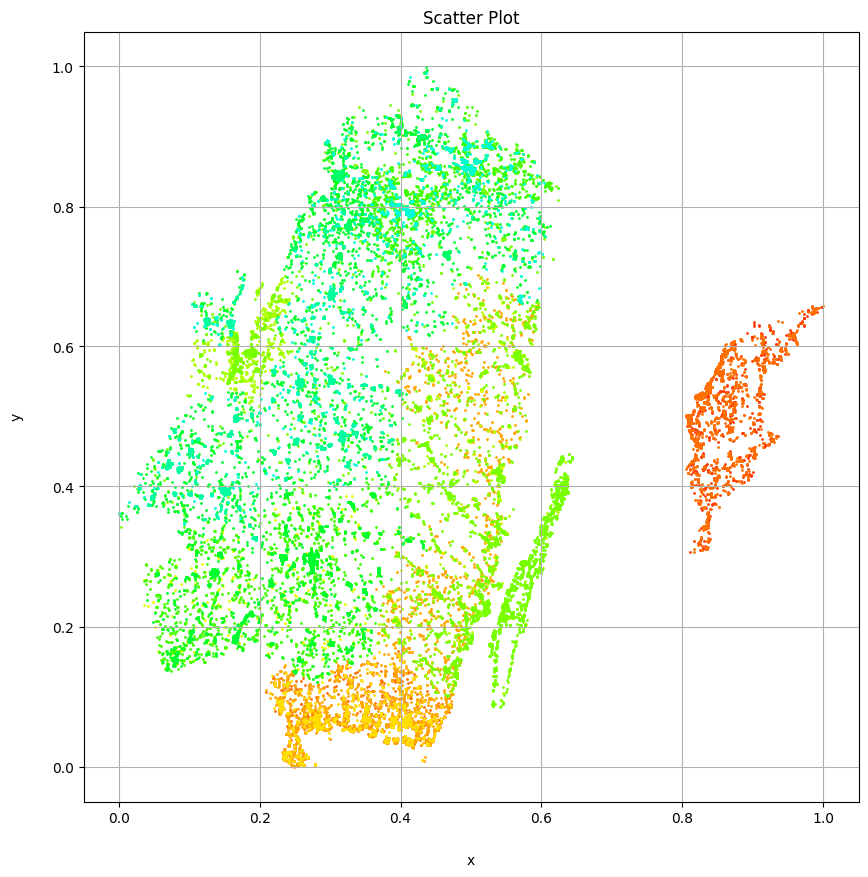

In [5]:
optimal_clustering = pd.DataFrame.to_numpy(df)

sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(norm_data, sorted_clusters, number_of_clusters, clusterspan,2, 1)

In [6]:
def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector

def center_of_mass(number_of_clusters, clusters):

    cluster_centers = np.zeros((number_of_clusters, np.shape(clusters)[1]))
    # print(cluster_centers.shape)
    # print(clusters[np.where(clusters[:,0] == 1)])
    # balancing_vector = np.zeros_like
    for i in range(1, number_of_clusters+1):
        cluster_x = clusters[np.where(clusters[:,0] == i)]
        # print(np.shape(cluster_x))
        cluster_centers[i-1,:] = np.sum(cluster_x, axis=0) / np.shape(cluster_x)[0]

    return cluster_centers


def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

centers_of_mass = center_of_mass(number_of_clusters, sorted_clusters)
print(centers_of_mass)
transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

# norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
print(np.shape(embedded_data))
# print(norm_embedded_data)

[[ 1.          0.51144746  0.85970098 ...  0.43037055  0.30422858
   0.47005654]
 [ 2.          0.22791844  0.52053531 ...  0.67202716  0.36216326
   0.71339303]
 [ 3.          0.14523989  0.3701001  ...  0.81806279  0.39098062
   0.84559795]
 ...
 [11.          0.60621666  0.26353381 ...  0.          0.22606093
   0.        ]
 [12.          0.51106988  0.21528423 ...  0.77906884  0.35957938
   0.816133  ]
 [13.          0.77638041  0.41372802 ...  0.          0.22606093
   0.        ]]
(73304, 13)


In [7]:

model = LinearRegression()

embedded_testing_data = (transformation_matrix@norm_testing_data.T).T

model.fit(embedded_data, norm_targets)
prediction = model.predict(embedded_testing_data)

print(prediction, norm_testing_targets, 'diff:', np.mean(abs(prediction-norm_testing_targets)))


[[0.67986997]
 [0.58703727]
 [0.51650433]
 ...
 [0.45057138]
 [0.45569713]
 [0.50724078]] [[0.72797624]
 [0.57633386]
 [0.58252579]
 ...
 [0.42954985]
 [0.51342152]
 [0.50529674]] diff: 0.07109951315267089


In [8]:
model = LinearRegression()

# embedded_testing_data = (transformation_matrix@norm_testing_data.T).T

model.fit(norm_data, norm_targets)
prediction = model.predict(norm_testing_data)

print(prediction, norm_testing_targets, 'diff:', np.mean(abs(prediction-norm_testing_targets)))


[[0.72786783]
 [0.55811303]
 [0.5321896 ]
 ...
 [0.32638515]
 [0.44918563]
 [0.52951299]] [[0.72797624]
 [0.57633386]
 [0.58252579]
 ...
 [0.42954985]
 [0.51342152]
 [0.50529674]] diff: 0.04910378710485301
